### 1. Importing Data and Libraries

In [9]:
!pip install PyPDF2

In [10]:
import pandas as pd
import numpy as np
import kagglehub

import os
import cv2
import PyPDF2

from PIL import Image
import matplotlib.pyplot as plt

In [11]:
# Download latest version
path = kagglehub.dataset_download("snehaanbhawal/resume-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'resume-dataset' dataset.
Path to dataset files: /kaggle/input/resume-dataset


In [12]:
path += "/data/data/ENGINEERING"

### 2. Loading the files

In [13]:
all_files = [f for f in os.listdir(path) if f.lower().endswith(".pdf")]
print("Total PDF files found:", len(all_files))

# Pick first 5 PDFs
sample_files = all_files[:5]
print("\nTop 5 PDF files:")
for f in sample_files:
    print(" -", f)

# Function to extract text from a PDF
def extract_pdf_text(pdf_path):
    text = ""
    with open(pdf_path, "rb") as f:
        reader = PyPDF2.PdfReader(f)
        for page in reader.pages:
            text += page.extract_text() or ""
    return text.strip()

# Read the PDFs
docs = {}
for f in sample_files:
    fpath = os.path.join(path, f)
    docs[f] = extract_pdf_text(fpath)


Total PDF files found: 118

Top 5 PDF files:
 - 19124258.pdf
 - 14206561.pdf
 - 11890896.pdf
 - 21629057.pdf
 - 28320387.pdf


### 3. PDF to Image

In [14]:
!pip install pdf2image
!apt-get install -y poppler-utils

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  poppler-utils
0 upgraded, 1 newly installed, 0 to remove and 35 not upgraded.
Need to get 186 kB of archives.
After this operation, 697 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy-updates/main amd64 poppler-utils amd64 22.02.0-2ubuntu0.10 [186 kB]
Fetched 186 kB in 0s (2,068 kB/s)
Selecting previously unselected package poppler-utils.
(Reading database ... 126435 files and directories currently installed.)
Preparing to unpack .../poppler-utils_22.02.0-2ubuntu0.10_amd64.deb ...
Unpacking poppler-utils (22.02.0-2ubuntu0.10) ...
Setting up poppler-utils (22.02.0-2ubuntu0.10) ...
Processing triggers for man-db (2.10.2-1) ...


In [15]:
from pdf2image import convert_from_path

# Output folder for images
output_dir = "/content/converted_images"
os.makedirs(output_dir, exist_ok=True)

# Convert first page of each PDF
for f in sample_files:
    pdf_path = os.path.join(path, f)
    images = convert_from_path(pdf_path, first_page=1, last_page=1, dpi=200)  # only first page

    # Save as PNG
    image_path = os.path.join(output_dir, f"{os.path.splitext(f)[0]}_page1.png")
    images[0].save(image_path, "PNG")
    print(f"Saved image: {image_path}")


Saved image: /content/converted_images/19124258_page1.png
Saved image: /content/converted_images/14206561_page1.png
Saved image: /content/converted_images/11890896_page1.png
Saved image: /content/converted_images/21629057_page1.png
Saved image: /content/converted_images/28320387_page1.png


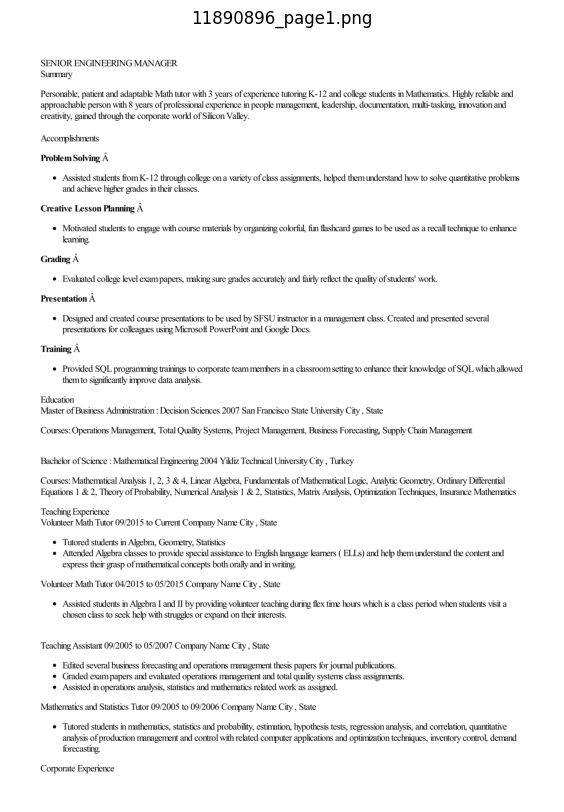

In [17]:
# Pick one converted image
output_dir = "/content/converted_images"
all_images = [f for f in os.listdir(output_dir) if f.lower().endswith(".png")]

# Load the first image
img_path = os.path.join(output_dir, all_images[0])
img = Image.open(img_path)

# Plot the image
plt.figure(figsize=(8, 10))
plt.imshow(img)
plt.axis('off')  # hide axes
plt.title(all_images[0])
plt.show()


### 4. Image Preprocessing

In [18]:
def convert_to_grayscale(image):
  return cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

def reduce_noise(gray_image):
  return cv2.GaussianBlur(gray_image, (5, 5), 0)

def binarize_image(blur_reduced_image):
  return cv2.adaptiveThreshold(
    blur_reduced_image,
    255,
    cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv2.THRESH_BINARY_INV, # Invert the colors (text becomes white)
    11, # Block size
    4  # Constant C
  )

def deskew_image(image):
    """
    Corrects the skew of an image by finding the minimum area rectangle
    of the text block and rotating accordingly.
    """
    # Find all non-zero (white) pixels
    coords = cv2.findNonZero(image)

    # Get the minimum area bounding rectangle
    # It returns (center(x,y), (width, height), angle of rotation)
    rect = cv2.minAreaRect(coords)
    angle = rect[-1] - 90

    # The `cv2.minAreaRect` angle has a specific range.
    # We need to adjust it for our rotation.
    if angle < -45:
        angle = -(90 + angle)
    else:
        angle = angle

    # Get the rotation matrix and rotate the image
    (h, w) = image.shape[:2]
    center = (w // 2, h // 2)
    M = cv2.getRotationMatrix2D(center, angle, 1.0)
    rotated = cv2.warpAffine(image, M, (w, h),
                             flags=cv2.INTER_CUBIC,
                             borderMode=cv2.BORDER_REPLICATE)
    print(f"Detected skew angle: {angle:.2f} degrees")

    # Now, rotate the original grayscale image by the same angle
    (h, w) = rotated.shape
    center = (w // 2, h // 2)
    M = cv2.getRotationMatrix2D(center, angle, 1.0)
    deskewed_gray = cv2.warpAffine(rotated, M, (w, h),
                                  flags=cv2.INTER_CUBIC,
                                  borderMode=cv2.BORDER_REPLICATE)

    return deskewed_gray

In [19]:
def process_one_image(image):
  image = convert_to_grayscale(image)
  print("Converted image to grayscale..")
  image = reduce_noise(image)
  print("Reduced noise in the image..")
  image = binarize_image(image)
  print("Binarized the image..")
  image = deskew_image(image)
  print("Corrected image orientation..")
  return image

In [20]:
import time

# Folder where the converted PDF images are stored
input_folder = "/content/converted_images"  # Colab folder from previous conversion
output_folder = "/content/processed_images"

# Create output folder if it doesn't exist
os.makedirs(output_folder, exist_ok=True)
print(f"Output folder ready: {output_folder}")

start_time = time.time()

# List first 20 images (or all if fewer)
image_files = [f for f in os.listdir(input_folder) if f.lower().endswith((".png", ".jpg", ".jpeg"))]
print(image_files)
for image_name in image_files:
    print(f"Processing image: {image_name}")

    # Load image
    image_path = os.path.join(input_folder, image_name)
    image = cv2.imread(image_path)

    # Process image (make sure you have defined this function)
    processed_image = process_one_image(image)

    # Save processed image
    output_path = os.path.join(output_folder, image_name)
    cv2.imwrite(output_path, processed_image)

    print(f"Saved processed image to: {output_path}")
    print("-" * 50)

print("Processing completed.")
print(f"Total time taken: {time.time() - start_time:.2f} seconds")


Output folder ready: /content/processed_images
['11890896_page1.png', '21629057_page1.png', '28320387_page1.png', '19124258_page1.png', '14206561_page1.png']
Processing image: 11890896_page1.png
Converted image to grayscale..
Reduced noise in the image..
Binarized the image..
Detected skew angle: -0.04 degrees
Corrected image orientation..
Saved processed image to: /content/processed_images/11890896_page1.png
--------------------------------------------------
Processing image: 21629057_page1.png
Converted image to grayscale..
Reduced noise in the image..
Binarized the image..
Detected skew angle: -0.03 degrees
Corrected image orientation..
Saved processed image to: /content/processed_images/21629057_page1.png
--------------------------------------------------
Processing image: 28320387_page1.png
Converted image to grayscale..
Reduced noise in the image..
Binarized the image..
Detected skew angle: -0.03 degrees
Corrected image orientation..
Saved processed image to: /content/processed_i

### 5. Text Extraction: Tesseract

In [21]:
!pip install pytesseract pillow

In [28]:
from PIL import Image
import pytesseract
import time

input_folder_path = "/content/processed_images"
output_folder_path = "/content/tesseract_output"
start_time = time.time()

if os.makedirs(output_folder_path, exist_ok=True):
  print(f"Created folder: {output_folder_path}")

total_images = sum(1 for entry in os.scandir(input_folder_path))
print(f"Total images in folder: {total_images}")

for i, image_name in enumerate(os.listdir(input_folder_path)[:5], 1):
  print(f"Processing image {i}/{total_images}: {image_name}")
  image_path = os.path.join(input_folder_path, image_name)
  print("Extracting text from image..")
  text = pytesseract.image_to_string(Image.open(image_path))
  output_path = os.path.join(output_folder_path, image_name.replace(".png", ".txt"))
  with open(output_path, "w") as f:
    f.write(text)

  print(f"Saved extracted text to {output_path}")
  print("-"*50)

print("Text Extraction Completed.")
print(f"Total time taken: {time.time() - start_time} seconds")

Total images in folder: 5
Processing image 1/5: 11890896_page1.png
Extracting text from image..
Saved extracted text to /content/tesseract_output/11890896_page1.txt
--------------------------------------------------
Processing image 2/5: 21629057_page1.png
Extracting text from image..
Saved extracted text to /content/tesseract_output/21629057_page1.txt
--------------------------------------------------
Processing image 3/5: 28320387_page1.png
Extracting text from image..
Saved extracted text to /content/tesseract_output/28320387_page1.txt
--------------------------------------------------
Processing image 4/5: 19124258_page1.png
Extracting text from image..
Saved extracted text to /content/tesseract_output/19124258_page1.txt
--------------------------------------------------
Processing image 5/5: 14206561_page1.png
Extracting text from image..
Saved extracted text to /content/tesseract_output/14206561_page1.txt
--------------------------------------------------
Text Extraction Complete

### 6. Prompt creation

In [24]:
prompt = """
Extract the following information from the resume text:
- name
- email
- phone
- education
- skills
- experience

The resume text has been extracted using OCR/NLP preprocessing.

Output strictly in this JSON format:
{
    "name": "FULL_NAME",
    "email": "EMAIL",
    "phone": "PHONE_NUMBER",
    "education": ["EDUCATION_DETAILS"],
    "skills": ["SKILL_1", "SKILL_2", ...],
    "experience": ["EXPERIENCE_DETAILS"]
}

If OCR/NLP extraction is inaccurate, correct it before responding.
If any field is missing, return it as an empty string or empty list.
Only return the JSON — no explanations.

Here is the extracted text:
"""

### 7. LLM Invocation

In [25]:
from google import genai
from google.colab import userdata # colab only code
from PIL import Image
import json
import time

In [26]:
genai_client = genai.Client(api_key=userdata.get('GOOGLE_API_KEY'))

In [30]:
image_folder_path = "/content/processed_images"
text_folder_path = "/content/tesseract_output"
output_folder_path = "/content/json_output"

start_time = time.time()

if os.makedirs(output_folder_path, exist_ok=True):
  print(f"Created folder: {output_folder_path}")

total_images = sum(1 for entry in os.scandir(image_folder_path))
print(f"Total images in folder: {total_images}")

for i, image_name in enumerate(os.listdir(input_folder_path)[:5], 1):
  print(f"Processing image {i}/{total_images}: {image_name}")
  image_path = os.path.join(input_folder_path, image_name)
  print(f"Loading image: {image_path}")
  with open(image_path, "rb") as f:
    image = Image.open(image_path)


  text_path = os.path.join(text_folder_path, image_name.replace(".png", ".txt"))
  print(f"Loading extracted text: {text_path}")
  with open(text_path, "r") as f:
    text = f.read()

  print("Extracting information from image and text..")

  prompt = prompt + text



  contents = [
        image,
        {
            "text": prompt
        }
    ]
  response = genai_client.models.generate_content(model='gemini-1.5-flash', contents=contents)

  # Access the usage_metadata attribute
  usage_metadata = response.usage_metadata

  # Print the different token counts
  print(f"Input Token Count: {usage_metadata.prompt_token_count}")
  print(f"Thoughts Token Count: {response.usage_metadata.thoughts_token_count}")
  print(f"Output Token Count: {usage_metadata.candidates_token_count}")
  print(f"Total Token Count: {usage_metadata.total_token_count}")

  extracted_information = json.loads(response.text.replace('```json', '').replace('```', ''))
  output_path = os.path.join(output_folder_path, image_name.replace(".png", ".json"))
  with open(output_path, "w") as f:
    json.dump(extracted_information, f, indent=4)

  print(f"Saved extracted information to {output_path}")
  print("-"*50)
  time.sleep(60)

print("Information Extraction Completed.")
print(f"Total time taken: {time.time() - start_time} seconds")

Total images in folder: 5
Processing image 1/5: 11890896_page1.png
Loading image: /content/processed_images/11890896_page1.png
Loading extracted text: /content/tesseract_output/11890896_page1.txt
Extracting information from image and text..
Input Token Count: 5260
Thoughts Token Count: None
Output Token Count: 411
Total Token Count: 5671
Saved extracted information to /content/json_output/11890896_page1.json
--------------------------------------------------
Processing image 2/5: 21629057_page1.png
Loading image: /content/processed_images/21629057_page1.png
Loading extracted text: /content/tesseract_output/21629057_page1.txt
Extracting information from image and text..
Input Token Count: 6214
Thoughts Token Count: None
Output Token Count: 856
Total Token Count: 7070
Saved extracted information to /content/json_output/21629057_page1.json
--------------------------------------------------
Processing image 3/5: 28320387_page1.png
Loading image: /content/processed_images/28320387_page1.png